A model score has no meaning by itself. An RMSE of 7 might be excellent, ordinary, or useless depending on the target and on what a simpler method can already do.

This notebook builds a small regression evaluation from scratch. The goal is not to find the fanciest model; it is to make every improvement answer a fair question:

> Does this model predict unseen cases better than a cheap, honest baseline?

## Three rules before modeling

1. **Choose the split before inspecting test performance.** The test set represents the future, not a tuning surface.
2. **Fit every learned quantity on training data only.** That includes imputation values, scaling parameters, and the baseline mean.
3. **Use at least two views of error.** MAE is easy to interpret; RMSE reacts more strongly to large misses.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
n = 240
data = pd.DataFrame({
    "study_hours": rng.uniform(0, 12, n),
    "prior_score": rng.normal(68, 11, n).clip(30, 98),
    "sleep_hours": rng.normal(7, 1.1, n).clip(4, 10),
})
noise = rng.normal(0, 5.5, n)
data["exam_score"] = (
    18 + 3.0 * data.study_hours + 0.55 * data.prior_score +
    1.4 * data.sleep_hours + noise
).clip(0, 100)

train = data.iloc[:180].copy()
test = data.iloc[180:].copy()
data.head().round(1)

,study_hours,prior_score,sleep_hours,exam_score
0,7.5,67.0,5.0,86.4
1,10.8,67.8,9.0,96.2
2,9.3,52.1,6.6,82.0
3,2.7,62.9,7.3,67.6
4,3.6,76.2,7.0,78.6


We preserve row order rather than randomly reshuffling. In a real project, the correct split follows how predictions will be used: future dates for forecasting, unseen customers for customer-level generalization, or unseen locations for geographic transfer.

## Establish the floor

The baseline always predicts the **training-set mean**. It is deliberately simple. If a trained model cannot beat it on held-out data, the extra machinery has not earned its place.

In [2]:
def mae(actual, predicted):
    return np.mean(np.abs(np.asarray(actual) - np.asarray(predicted)))

def rmse(actual, predicted):
    return np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted)) ** 2))

baseline_prediction = np.repeat(train.exam_score.mean(), len(test))
pd.Series({
    "baseline_MAE": mae(test.exam_score, baseline_prediction),
    "baseline_RMSE": rmse(test.exam_score, baseline_prediction),
}).round(2)

baseline_MAE      9.45
baseline_RMSE    11.10
dtype: float64

## Fit one understandable model

Ordinary least squares is a strong first model for continuous targets. We add a column of ones for the intercept and solve for the coefficients with `numpy.linalg.lstsq`.

In [3]:
features = ["study_hours", "prior_score", "sleep_hours"]
X_train = np.column_stack([np.ones(len(train)), train[features].to_numpy()])
X_test = np.column_stack([np.ones(len(test)), test[features].to_numpy()])

coefficients, *_ = np.linalg.lstsq(X_train, train.exam_score, rcond=None)
model_prediction = X_test @ coefficients

pd.Series(coefficients, index=["intercept", *features]).round(3)

intercept      15.941
study_hours     2.768
prior_score     0.550
sleep_hours     1.778
dtype: float64

In [4]:
scorecard = pd.DataFrame([
    {"model": "Training-mean baseline", "MAE": mae(test.exam_score, baseline_prediction), "RMSE": rmse(test.exam_score, baseline_prediction)},
    {"model": "Linear regression", "MAE": mae(test.exam_score, model_prediction), "RMSE": rmse(test.exam_score, model_prediction)},
])
scorecard.assign(
    MAE=lambda frame: frame.MAE.round(2),
    RMSE=lambda frame: frame.RMSE.round(2),
)

,model,MAE,RMSE
0,Training-mean baseline,9.45,11.10
1,Linear regression,4.29,5.46


The useful number is the **gap from the baseline**. Here, the feature-based model should reduce both metrics substantially. MAE says how far away a typical prediction is in score points; the larger RMSE tells us that some misses are meaningfully worse than the average miss.

## Look past the aggregate

Averages can hide structure. Residuals—actual minus predicted—should not fan out, bend systematically, or cluster by a subgroup that matters.

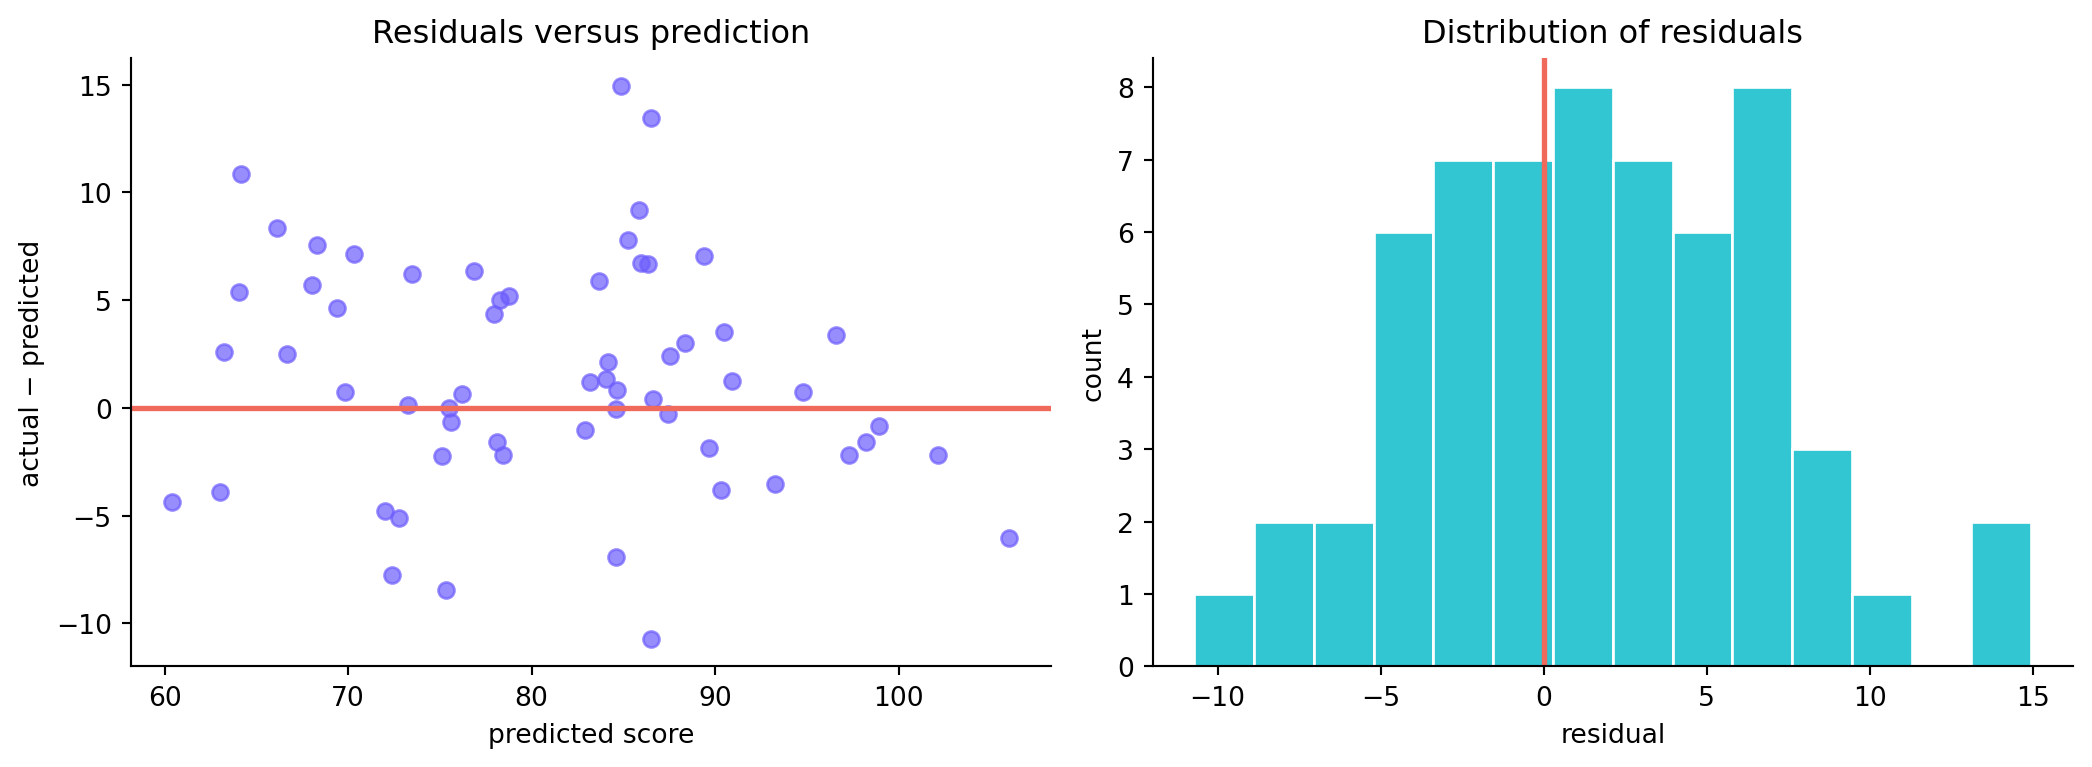

In [5]:
residuals = test.exam_score.to_numpy() - model_prediction
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))

axes[0].scatter(model_prediction, residuals, color="#6d5dfc", alpha=.7)
axes[0].axhline(0, color="#ef6a5b", linewidth=2)
axes[0].set(title="Residuals versus prediction", xlabel="predicted score", ylabel="actual − predicted")

axes[1].hist(residuals, bins=14, color="#32c5d2", edgecolor="white")
axes[1].axvline(0, color="#ef6a5b", linewidth=2)
axes[1].set(title="Distribution of residuals", xlabel="residual", ylabel="count")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## One tiny leak is still a leak

It is tempting to compute the baseline from all rows because a global mean looks harmless. But the test targets would then influence the prediction used to score those same targets. In a real pipeline, similar leakage through scaling, imputation, or feature selection can create much larger illusions.

In [6]:
honest_mean = train.exam_score.mean()
leaky_mean = data.exam_score.mean()
pd.DataFrame({
    "baseline": ["training mean (valid)", "all-data mean (leaky)"],
    "value used": [honest_mean, leaky_mean],
    "test MAE": [
        mae(test.exam_score, np.repeat(honest_mean, len(test))),
        mae(test.exam_score, np.repeat(leaky_mean, len(test))),
    ],
}).round(2)

,baseline,value used,test MAE
0,training mean (valid),82.33,9.45
1,all-data mean (leaky),82.41,9.44


## A reusable evaluation checklist

- Define the prediction unit and the future use case.
- Split in a way that matches that use case.
- Fit the baseline and every preprocessing choice on training data only.
- Compare at least one interpretable error metric and one tail-sensitive metric.
- Inspect residuals and important subgroups.
- Report the improvement over baseline, not just the final score.

**Try next:** add an interaction term `study_hours * prior_score`. Keep it only if the held-out score improves and the change makes sense for the problem.